# VLM Visual Agnosia Experiment

**Research Question:** Do VLMs show human-like patterns of object recognition failure under degraded or fragmented visual input, mirroring the dissociations seen in apperceptive vs. associative visual agnosia?

**Hypothesis:** VLMs will pass degraded line drawings (where bottom-up feature matching is possible) but fail Mooney images (which require top-down global form completion before any recognition is possible). This would suggest their visual processing is texture/feature-based rather than genuinely perceptual, consistent with Marjieh et al.'s finding that visual input does not add perceptual structure beyond what language already captures.

## 1. Setup

In [30]:
from openai import OpenAI
from dotenv import load_dotenv
import os
import base64
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

# Models to test — all accept image inputs
# Note: gemini-3-flash-preview is listed on /v1/models but returns 400 on chat/completions.
# gemini-3.1-flash-lite-preview returns null content for vision inputs.
# claude-sonnet-4-5 and gpt-5.4 are confirmed working.
MODELS = [
    "claude-sonnet-4-5",   # Anthropic — confirmed working
    "gpt-5.4",             # OpenAI — confirmed working
]
# NOTE: gemini-2.5-pro returns 400 on this endpoint despite being listed at /v1/models
# gpt-5.2 also works but gpt-5.4 is more capable

print("Setup complete.")
print("Active models:", MODELS)

## 2. Load Stimuli

Place your images in the following folders:
- `stimuli/mooney/` — Mooney (two-tone) images, named by object (e.g. `dog_mooney.png`)
- `stimuli/degraded/` — Degraded line drawings of the same objects (e.g. `dog_degraded.png`)

Each Mooney image should have a matching degraded image of the **same object**.

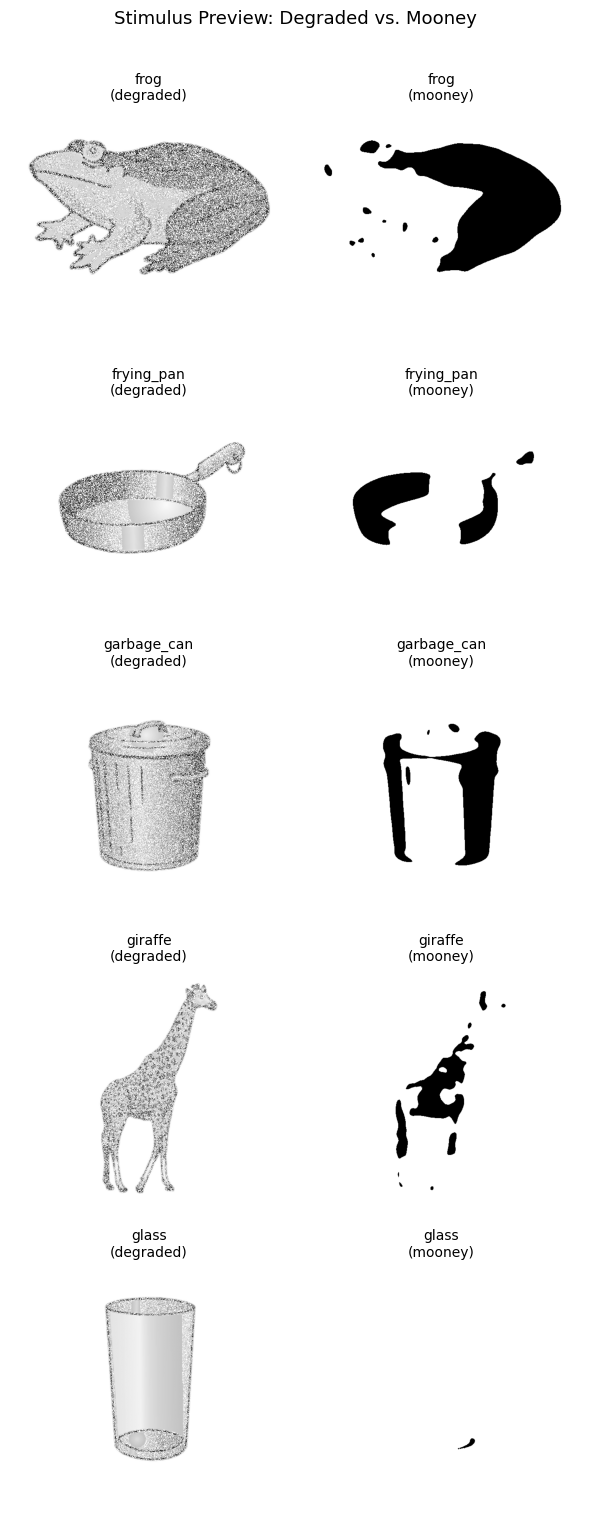

In [23]:
def preview_stimuli(mooney_dir="stimuli/mooney", degraded_dir="stimuli/degraded", n=5):
    """
    Display n matched pairs side by side: degraded (left) vs. Mooney (right).
    """
    mooney_files = sorted([
        f for f in os.listdir(mooney_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    samples = mooney_files[:n]

    fig, axes = plt.subplots(n, 2, figsize=(6, n * 3))
    if n == 1:
        axes = [axes]

    for i, fname in enumerate(samples):
        label = os.path.splitext(fname)[0]

        degraded_path = os.path.join(degraded_dir, fname)
        mooney_path = os.path.join(mooney_dir, fname)

        degraded_img = Image.open(degraded_path).convert("L") if os.path.exists(degraded_path) else None
        mooney_img = Image.open(mooney_path).convert("L") if os.path.exists(mooney_path) else None

        if degraded_img:
            axes[i][0].imshow(degraded_img, cmap="gray")
            axes[i][0].set_title(f"{label}\n(degraded)", fontsize=10)
        axes[i][0].axis("off")

        if mooney_img:
            axes[i][1].imshow(mooney_img, cmap="gray")
            axes[i][1].set_title(f"{label}\n(mooney)", fontsize=10)
        axes[i][1].axis("off")

    plt.suptitle("Stimulus Preview: Degraded vs. Mooney", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


preview_stimuli(n=5)

## 2b. Preview Stimuli

Run this cell after generating stimuli to visually inspect a few matched pairs before running the experiment.

## 2c. Load Validated Stimuli (with published human norms)

Replaces algorithmically-generated stimuli with datasets where the **exact same images** were tested on human participants.

- **FAOT** (Colman et al., 2019): 100 fragmented images, recognizability norms from 120 humans
- **Mooney**: MoonBase (Imamoglu et al., 2012) if received; Reining & Wallis (2024) as fallback

Run `python download_validated_stimuli.py` first to fetch the images.

In [31]:
def load_validated_stimuli(faot_dir="stimuli/faot",
                            faot_norms="stimuli/faot_norms.csv",
                            mooney_dir="stimuli/mooney_validated",
                            mooney_norms=None):
    """
    Load validated stimuli where human norms exist for the exact same images.

    Returns:
        stimuli  — list of dicts {label, condition, path} for the experiment runner
        norms_df — DataFrame with per-image human recognizability scores
    """
    import csv

    stimuli = []
    norms_rows = []

    # --- FAOT: fragmented objects ---
    if os.path.exists(faot_dir) and os.path.exists(faot_norms):
        with open(faot_norms, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            faot_norms_data = list(reader)

        for row in faot_norms_data:
            img_path = os.path.join(faot_dir, row["image_id"])
            if os.path.exists(img_path):
                stimuli.append({
                    "label":     row["label"],
                    "condition": "faot_fragmented",
                    "path":      img_path,
                })
                norms_rows.append({
                    "image_id":           row["image_id"],
                    "label":              row["label"],
                    "condition":          "faot_fragmented",
                    "human_recognizability": float(row["recognizability"]),
                    "source":             "Colman et al. (2019) — 120 observers",
                })
        print(f"FAOT: loaded {sum(1 for s in stimuli if s['condition'] == 'faot_fragmented')} images")
    else:
        print("FAOT not found — run: python download_validated_stimuli.py")

    # --- Mooney: validated images ---
    if os.path.exists(mooney_dir):
        mooney_files = [f for f in os.listdir(mooney_dir)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for fname in sorted(mooney_files):
            label = os.path.splitext(fname)[0].replace("_", " ").lower()
            stimuli.append({
                "label":     label,
                "condition": "mooney_validated",
                "path":      os.path.join(mooney_dir, fname),
            })
        print(f"Mooney validated: loaded {len(mooney_files)} images")

        if mooney_norms and os.path.exists(mooney_norms):
            with open(mooney_norms, newline="", encoding="utf-8") as f:
                reader = csv.DictReader(f)
                for row in reader:
                    norms_rows.append({
                        "image_id":              row.get("image_id", row.get("ID", "")),
                        "label":                 row.get("label", ""),
                        "condition":             "mooney_validated",
                        "human_recognizability": float(row.get("recognizability", 0)),
                        "source":                "MoonBase — Imamoglu et al. (2012)",
                    })
        else:
            print("  NOTE: No Mooney norms file found — awaiting MoonBase dataset.")
    else:
        print("Mooney validated not found — run: python download_validated_stimuli.py --mooney")

    norms_df = pd.DataFrame(norms_rows) if norms_rows else pd.DataFrame()
    print(f"\nTotal validated stimuli: {len(stimuli)}")
    return stimuli, norms_df


def plot_vlm_vs_human_per_image(results_df, norms_df, condition="faot_fragmented"):
    """
    Scatter plot: human recognizability (x) vs. VLM accuracy (y) per image.
    Each point is one image. A diagonal line = perfect alignment.
    """
    subset = results_df[results_df["condition"] == condition]
    vlm_acc = subset.groupby("label")["correct"].mean().reset_index()
    vlm_acc.columns = ["label", "vlm_accuracy"]

    norms_sub = norms_df[norms_df["condition"] == condition][["label", "human_recognizability"]]
    merged = vlm_acc.merge(norms_sub, on="label", how="inner")

    if merged.empty:
        print("No matched labels between VLM results and human norms.")
        return

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(merged["human_recognizability"], merged["vlm_accuracy"], alpha=0.6)
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect alignment")
    ax.set_xlabel("Human recognizability (Colman et al., 2019)")
    ax.set_ylabel("VLM accuracy")
    ax.set_title(f"Per-image: Human vs. VLM\n({condition})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend()

    corr = merged[["human_recognizability", "vlm_accuracy"]].corr().iloc[0, 1]
    ax.text(0.05, 0.92, f"r = {corr:.2f}", transform=ax.transAxes, fontsize=11)

    plt.tight_layout()
    plt.savefig(f"vlm_vs_human_{condition}.png", dpi=150)
    plt.show()
    return merged


# Load validated stimuli
validated_stimuli, norms_df = load_validated_stimuli()
print()
print(norms_df.groupby("condition")[["human_recognizability"]].describe().round(2) if not norms_df.empty else "No norms loaded yet.")


FAOT: loaded 100 images
Mooney validated not found — run: python download_validated_stimuli.py --mooney

Total validated stimuli: 100

                human_recognizability                                        
                                count mean   std   min   25%  50%   75%   max
condition                                                                    
faot_fragmented                 100.0  0.5  0.22  0.14  0.32  0.5  0.68  0.94


In [32]:
def load_stimuli(stimuli_dir="stimuli"):
    """
    Load stimuli from all conditions:
      - mooney/          standard two-tone Mooney
      - mooney_inverted/ contamination control (inverted Mooney)
      - degraded_25/     25% of line pixels removed
      - degraded_50/     50% of line pixels removed
      - degraded_75/     75% of line pixels removed

    Returns a list of dicts: {label, condition, path}
    Only includes images where all 5 conditions have a matching file.
    """
    conditions = {
        "mooney":        os.path.join(stimuli_dir, "mooney"),
        "mooney_inv":    os.path.join(stimuli_dir, "mooney_inverted"),
        "degraded_25":   os.path.join(stimuli_dir, "degraded_25"),
        "degraded_50":   os.path.join(stimuli_dir, "degraded_50"),
        "degraded_75":   os.path.join(stimuli_dir, "degraded_75"),
        "degraded_90":   os.path.join(stimuli_dir, "degraded_90"),
    }

    # Find labels present in every condition folder
    label_sets = []
    for cname, cdir in conditions.items():
        files = {os.path.splitext(f)[0] for f in os.listdir(cdir)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))}
        label_sets.append(files)

    matched_labels = sorted(set.intersection(*label_sets))
    print(f"Found {len(matched_labels)} objects matched across all {len(conditions)} conditions.")

    stimuli = []
    for label in matched_labels:
        for cname, cdir in conditions.items():
            stimuli.append({
                "label":     label,
                "condition": cname,
                "path":      os.path.join(cdir, f"{label}.png")
            })

    return stimuli


def encode_image(path):
    """Encode image to base64 string for API."""
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


stimuli = load_stimuli()
pd.DataFrame(stimuli).groupby("condition").size().rename("n_trials")


Found 161 objects matched across all 6 conditions.


condition
degraded_25    161
degraded_50    161
degraded_75    161
degraded_90    161
mooney         161
mooney_inv     161
Name: n_trials, dtype: int64

## 3. Prompting

We use a simple forced-choice prompt: the model must name the object in the image.
We collect:
- The model's text response
- Whether it matches the true label (correct/incorrect)

To control for prompt sensitivity (autoregressive artifact confound), we use the same prompt across all conditions and models.

In [33]:
SYSTEM_PROMPT = "You are participating in an object recognition experiment. Respond with only the name of the object you see — a single word or short noun phrase. Do not describe the image. Do not say you are unsure. Just name the object."

USER_PROMPT = "What object is in this image?"

# Synonym map: label (no underscores) -> list of accepted alternatives
SYNONYMS = {
    "garbage can":    ["trash can", "rubbish bin", "waste bin", "dustbin"],
    "gun":            ["revolver", "pistol", "firearm", "handgun"],
    "kettle":         ["teapot"],
    "pot":            ["saucepan", "cooking pot"],
    "pocketbook":     ["handbag", "purse", "wallet"],
    "wineglass":      ["goblet", "wine glass"],
    "sea horse":      ["seahorse"],
    "roller skate":   ["roller skates"],
    "tennis racket":  ["tennis racquet", "racket", "racquet"],
    "record player":  ["turntable", "gramophone", "phonograph"],
    "jacket":         ["coat", "blazer"],
    "seal":           ["sea lion"],
}


def query_model(model, image_path, system_prompt=SYSTEM_PROMPT, user_prompt=USER_PROMPT):
    """
    Send a single image to a VLM and return its text response.
    """
    image_data = encode_image(image_path)
    ext = os.path.splitext(image_path)[-1].lower().replace(".", "")
    mime = "image/jpeg" if ext in ("jpg", "jpeg") else "image/png"

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": f"data:{mime};base64,{image_data}"}},
                    {"type": "text", "text": user_prompt}
                ]
            }
        ],
        reasoning_effort=None
    )

    return response.choices[0].message.content.strip().lower()


def is_correct(response, true_label):
    """
    Check if the model's response matches the true object label.
    - Normalizes underscores to spaces before comparison
    - Accepts known synonyms
    - Rejects hallucinations: responses >8 words are not valid object names
    """
    resp = response.lower().strip()

    # Hallucination guard: valid object names are short
    if len(resp.split()) > 8:
        return False

    label = true_label.lower().replace("_", " ").strip()

    if label in resp:
        return True

    for syn in SYNONYMS.get(label, []):
        if syn.lower() in resp:
            return True

    return False


print("Prompting functions ready.")

Prompting functions ready.


## 4. Run Experiment

In [ ]:
def run_experiment(stimuli, models):
    """
    Run all stimuli through all models. Returns a DataFrame of results.
    """
    results = []

    for model in models:
        print(f"\nRunning model: {model}")
        for trial in tqdm(stimuli):
            response = query_model(model, trial["path"])
            correct = is_correct(response, trial["label"])
            results.append({
                "model":     model,
                "label":     trial["label"],
                "condition": trial["condition"],
                "response":  response,
                "correct":   correct
            })

    return pd.DataFrame(results)


# Load validated stimuli (FAOT fragmented + Mooney if available)
# These have published human norms for the exact same images.
validated_stimuli, norms_df = load_validated_stimuli()
results_df = run_experiment(validated_stimuli, MODELS)
results_df.to_csv("results.csv", index=False)
results_df.head()


## 5. Analysis & Plots

In [27]:
results_df = pd.read_csv("results.csv")

def plot_accuracy(results_df, norms_df=None):
    """
    Two panels:
      Left:  VLM accuracy vs. human recognizability per image (scatter) — FAOT
      Right: bar chart per condition, with human mean overlaid
    """
    conditions = results_df["condition"].unique()
    summary = results_df.groupby(["model", "condition"])["correct"].mean().reset_index()
    summary.columns = ["model", "condition", "accuracy"]
    models = summary["model"].unique()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: per-image scatter for FAOT ---
    ax = axes[0]
    if norms_df is not None and "faot_fragmented" in conditions:
        faot_results = results_df[results_df["condition"] == "faot_fragmented"]
        vlm_acc = faot_results.groupby("label")["correct"].mean().reset_index()
        vlm_acc.columns = ["label", "vlm_accuracy"]
        norms_sub = norms_df[norms_df["condition"] == "faot_fragmented"][["label", "human_recognizability"]]
        merged = vlm_acc.merge(norms_sub, on="label", how="inner")
        if not merged.empty:
            ax.scatter(merged["human_recognizability"], merged["vlm_accuracy"], alpha=0.6, color="#4C72B0")
            ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect alignment")
            corr = merged[["human_recognizability", "vlm_accuracy"]].corr().iloc[0, 1]
            ax.text(0.05, 0.92, f"r = {corr:.2f}", transform=ax.transAxes, fontsize=11)
            ax.set_xlabel("Human recognizability (Colman et al., 2019)")
            ax.set_ylabel("VLM accuracy")
            ax.set_title("Per-image alignment:\nVLM vs. Human (FAOT)")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.legend(fontsize=9)
    else:
        ax.text(0.5, 0.5, "Run load_validated_stimuli()\nand re-run experiment first",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Per-image scatter (FAOT)")

    # --- Right: accuracy bar per condition ---
    ax = axes[1]
    x = np.arange(len(conditions))
    width = 0.6 / len(models)
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
    for i, model in enumerate(models):
        vals = [summary[(summary["model"] == model) & (summary["condition"] == c)]["accuracy"].values
                for c in conditions]
        vals = [v[0] if len(v) else 0 for v in vals]
        ax.bar(x + i * width, vals, width, label=model.split("/")[-1], color=colors[i % len(colors)], alpha=0.85)

    # Human mean overlays
    if norms_df is not None:
        human_means = norms_df.groupby("condition")["human_recognizability"].mean()
        for j, cond in enumerate(conditions):
            if cond in human_means.index:
                ax.plot([x[j] - 0.3, x[j] + 0.3], [human_means[cond]] * 2,
                        color="black", linewidth=2, label="Human mean" if j == 0 else "")

    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels([c.replace("_", "\n") for c in conditions], fontsize=9)
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Accuracy by Condition\n(black lines = human mean)")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

    plt.suptitle("VLM Object Recognition — Validated Stimuli", fontsize=13)
    plt.tight_layout()
    plt.savefig("accuracy_by_condition.png", dpi=150)
    plt.show()
    return summary


plot_accuracy(results_df, norms_df)


## 6. Human Comparison

Human benchmark data from the literature:

- **Mooney images (objects):** ~34% spontaneous recognition before any disambiguation cue (Snodgrass & Corwin, 1988). Recognition of non-face Mooney objects is substantially lower than faces and highly variable.
- **Degraded line drawings (S&V fragmentation):** ~35% correct at threshold fragmentation level (Snodgrass & Corwin, 1988); up to ~63% for easier items (Koch et al., 1995).

**Caveat:** No published study provides human norms for exactly our degradation method (50% random line pixel removal). These numbers are the closest available approximation.

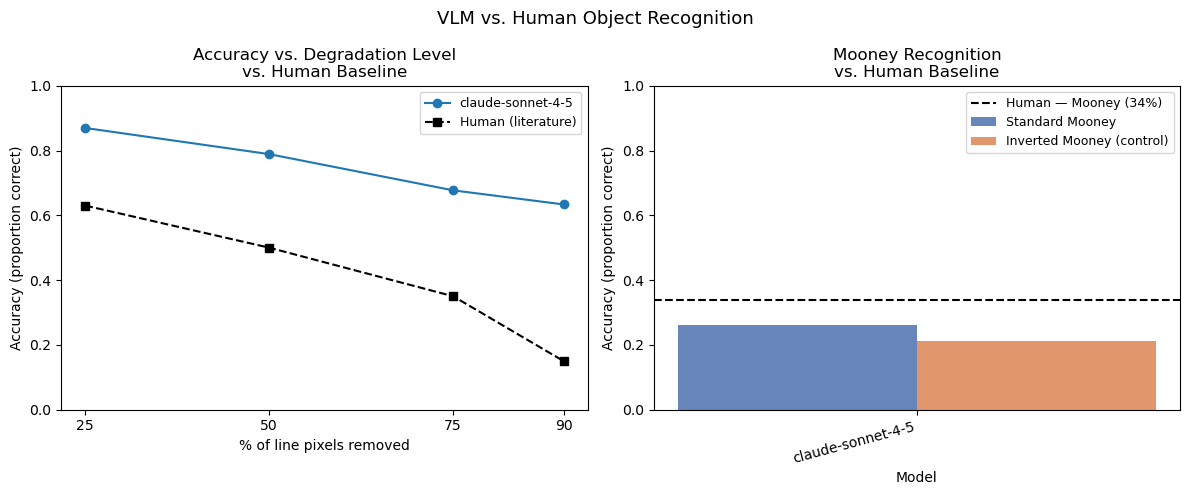

In [28]:
def plot_with_human_baseline(results_df,
                             human_mooney=0.34,
                             human_degraded={25: 0.63, 50: 0.50, 75: 0.35, 90: 0.15}):
    """
    Two-panel figure with human baselines overlaid.

    Human baselines (from Snodgrass & Corwin, 1988; Koch et al., 1995):
      - Mooney objects:         ~34% spontaneous recognition
      - Degraded 75% removed:  ~35% (threshold fragmentation)
      - Degraded 50% removed:  ~50% (interpolated)
      - Degraded 25% removed:  ~63% (easier items, Koch et al.)
    """
    summary = results_df.groupby(["model", "condition"])["correct"].mean().reset_index()
    summary.columns = ["model", "condition", "accuracy"]
    models = summary["model"].unique()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: degradation curve with human baseline ---
    ax = axes[0]
    degraded_conditions = ["degraded_25", "degraded_50", "degraded_75", "degraded_90"]
    x_vals = [25, 50, 75, 90]
    for model in models:
        y_vals = [
            summary[(summary["model"] == model) & (summary["condition"] == c)]["accuracy"].values[0]
            for c in degraded_conditions
        ]
        ax.plot(x_vals, y_vals, marker="o", label=model.split("/")[-1])
    human_y = [human_degraded[x] for x in x_vals]
    ax.plot(x_vals, human_y, marker="s", linestyle="--", color="black", label="Human (literature)")
    ax.set_xlabel("% of line pixels removed")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Accuracy vs. Degradation Level\nvs. Human Baseline")
    ax.set_xticks(x_vals)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

    # --- Right: Mooney bar with human baseline ---
    ax = axes[1]
    mooney_conditions = ["mooney", "mooney_inv"]
    x = np.arange(len(models))
    width = 0.35
    colors = ["#4C72B0", "#DD8452"]
    for i, cond in enumerate(mooney_conditions):
        vals = [
            summary[(summary["model"] == m) & (summary["condition"] == cond)]["accuracy"].values[0]
            for m in models
        ]
        label = "Standard Mooney" if cond == "mooney" else "Inverted Mooney (control)"
        ax.bar(x + i * width, vals, width, label=label, color=colors[i], alpha=0.85)
    ax.axhline(human_mooney, color="black", linestyle="--", linewidth=1.5,
               label=f"Human — Mooney ({human_mooney:.0%})")
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Mooney Recognition\nvs. Human Baseline")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([m.split("/")[-1] for m in models], rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

    plt.suptitle("VLM vs. Human Object Recognition", fontsize=13)
    plt.tight_layout()
    plt.savefig("accuracy_with_human_baseline.png", dpi=150)
    plt.show()


plot_with_human_baseline(results_df)


## 7. Error Type Analysis

Accuracy alone doesn't tell us *why* models fail. We categorize each incorrect trial to distinguish:
- **`semantic_neighbor`** — response is in the same category (e.g., `seal` → `walrus`, `toe` → `finger`)
- **`confabulation`** — response is unrelated or bizarre (e.g., `sandwich` → `tambourine`, `helicopter` → `shark`)
- **`part_whole`** — model names a part or superset of the object (e.g., `nose` → `face`, `thumb` → `finger`)

This dissociation maps onto apperceptive vs. associative agnosia: confabulations suggest the model is constructing a false percept from partial features (apperceptive-like), while semantic neighbors suggest the percept is formed but misidentified at the categorical level (associative-like).

In [29]:
# Semantic neighbor sets — objects that are easily confused
SEMANTIC_NEIGHBORS = {
    "seal":          ["walrus", "sea lion", "otter"],
    "toe":           ["finger", "thumb"],
    "thumb":         ["finger", "toe"],
    "mouse":         ["rat", "hamster", "gerbil"],
    "lettuce":       ["cabbage", "spinach", "salad"],
    "lips":          ["mouth"],
    "jacket":        ["coat", "shirt", "blazer"],
    "swan":          ["goose", "duck", "bird"],
    "sheep":         ["goat", "lamb", "cow"],
    "ring":          ["bracelet", "watch", "pocket watch"],
    "pencil":        ["pen", "marker", "crayon"],
    "paintbrush":    ["brush", "broom"],
    "tennis racket": ["badminton racket", "racket"],
    "thimble":       ["cup", "toaster"],
}

# Body part / part-whole confusion set
PART_WHOLE = {
    "nose":  ["face", "head"],
    "thumb": ["finger", "hand"],
    "toe":   ["finger", "foot"],
    "lips":  ["face", "mouth"],
    "hair":  ["head"],
    "leg":   ["body"],
}


def classify_error(response, true_label):
    """
    For an incorrect trial, classify the error type.
    Returns: 'hallucination', 'part_whole', 'semantic_neighbor', or 'confabulation'
    """
    resp = response.lower().strip()
    label = true_label.lower().replace("_", " ").strip()

    # Hallucination: model output unrelated text (not an object name)
    if len(resp.split()) > 8:
        return "hallucination"

    if label in PART_WHOLE:
        for pw in PART_WHOLE[label]:
            if pw in resp:
                return "part_whole"

    if label in SEMANTIC_NEIGHBORS:
        for neighbor in SEMANTIC_NEIGHBORS[label]:
            if neighbor in resp:
                return "semantic_neighbor"

    return "confabulation"


results_df = pd.read_csv("results.csv")

errors = results_df[results_df["correct"] == False].copy()
errors["error_type"] = errors.apply(
    lambda r: classify_error(r["response"], r["label"]), axis=1
)

print("Error counts by condition and type:")
print(errors.groupby(["condition", "error_type"]).size().unstack(fill_value=0))
print()
print("All errors with type:")
print(errors[["condition", "label", "response", "error_type"]].to_string())

# Plot: 3 panels — mooney, mooney_inv, and degraded (aggregated across levels)
# Aggregating degraded_25/50/75 gives a stable error-type estimate across all degradation
errors["condition_group"] = errors["condition"].apply(
    lambda c: "degraded (all levels)" if c.startswith("degraded") else c
)

results_df["condition_group"] = results_df["condition"].apply(
    lambda c: "degraded (all levels)" if c.startswith("degraded") else c
)

plot_conditions = ["mooney", "mooney_inv", "degraded (all levels)"]
condition_labels = ["Mooney", "Inverted Mooney\n(control)", "Degraded\n(all levels)"]
error_types = ["hallucination", "confabulation", "semantic_neighbor", "part_whole"]
colors = ["#8B0000", "#C44E52", "#4C72B0", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, cond, cond_label in zip(axes, plot_conditions, condition_labels):
    subset_errors = errors[errors["condition_group"] == cond]
    total = len(results_df[results_df["condition_group"] == cond])
    counts = [len(subset_errors[subset_errors["error_type"] == t]) for t in error_types]
    proportions = [c / total for c in counts]
    bars = ax.bar(error_types, proportions, color=colors)
    # Label each bar with count
    for bar, count in zip(bars, counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                    str(count), ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{cond_label}\n(n={total} trials)")
    ax.set_ylabel("Proportion of trials")
    ax.set_ylim(0, max(proportions) * 1.3 + 0.02)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle("Error Type Distribution by Condition", fontsize=13)
plt.tight_layout()
plt.savefig("error_type_analysis.png", dpi=150)
plt.show()
